---
authors:
  - name: Felix Drost
  - name: Lukas Heumos
    roles:
      - writing – review & editing
---


(air-repertoire-ir-profiling)=
# Immune receptor profiling
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #air-repertoire-ir-profiling-key-takeaway-1
T and B cells recognize antigens with receptors whose diversity arises from V(D)J recombination, and the CDR3 at the junction of the gene segments is their most diverse part.
:::

:::{card}
:link: #air-repertoire-ir-profiling-key-takeaway-2
Droplet-based V(D)J libraries are assembled with Cell Ranger, and BCRs should be re-annotated with IgBLAST to reconstruct germline sequences.
:::

:::{card}
:link: #air-repertoire-ir-profiling-key-takeaway-3
Cells with more than two chains of a type or with both TCR and BCR chains are likely doublets, and the receptor type should agree with the transcriptomic cell type.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} air_repertoire.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(air-repertoire-ir-profiling-key-takeaway-1)=
## Adaptive immune receptors

T and B cells recognize antigens with their adaptive immune receptors (AIRs), the T cell receptor (TCR) and the B cell receptor (BCR) {cite:p}`air:cooper2006evolution`.
TCRs bind peptides presented by major histocompatibility complex (MHC) molecules, whereas BCRs bind antigens directly and are secreted as antibodies by plasma cells.
Both receptors consist of two chains, an α and a β or a γ and a δ chain for TCRs and a heavy and a κ or λ light chain for BCRs.
We refer to the α, γ, κ and λ chains as VJ chains and to the β, δ and heavy chains as VDJ chains, after the gene segments that encode them.

:::{figure} ../_static/images/air_repertoire/AIR_types.png
:name: AIR types
:alt: AIR types
:class: bg-primary mb-1
:width: 800px

Schematic drawing of the two AIR types. Created with BioRender.com.
:::

Each developing lymphocyte assembles its receptor chains by {term}`V(D)J recombination` of one V, (D) and J gene segment and inserts or deletes nucleotides where they join.
This allows for about 10<sup>20</sup> different TCRs, of which a human carries 10<sup>7</sup> to 10<sup>8</sup> {cite:p}`air:zarnitsyna2013estimating,air:qi2014diversity`.
The third {term}`complementarity-determining region <Complementarity-determining region (CDR)>` (CDR3) spans these junctions and is therefore the most diverse part of each chain and its main contact with the antigen, whereas CDR1 and CDR2 are encoded by the V gene.
Activated B cells further diversify their receptors by {term}`somatic hypermutation <Somatic hypermutation (SHM)>` and switch the constant region of the heavy chain, which determines the antibody isotype.

:::{figure} ../_static/images/air_repertoire/VDJ_recombination.png
:name: VDJ recombination
:alt: VDJ recombination
:class: bg-primary mb-1
:width: 800px

VDJ recombination at the example of an αβ-TCR. Created with BioRender.com.
:::

Tools and databases report the CDR3 either as the {term}`junction <Junction>`, which includes the conserved cysteine and the phenylalanine or tryptophan that flank it, or without these residues.
The AIRR Rearrangement standard, which scirpy follows, stores both as separate fields, `junction` and `cdr3`, and sequences can only be compared between resources if they use the same definition {cite:p}`air:vanderheiden2018airr`.

(air-repertoire-ir-profiling-key-takeaway-2)=
## Sequencing immune receptors

Droplet-based protocols such as 10x Genomics 5' sequencing amplify the receptor transcripts of each cell into a V(D)J library next to the gene expression library.
Cell Ranger assembles these reads into contigs, annotates their gene segments and assigns them to cells.
Receptors can also be reconstructed from gene expression reads alone, for which TRUST4 and MiXCR perform best, but only with sufficient sequencing depth and read length {cite:p}`air:song2021trust4,air:bolotin2015mixcr,air:tian2025evaluation`.
For plate-based data with full-length transcripts, BraCeR and BALDR reconstruct mutated BCRs most accurately {cite:p}`air:andreani2022benchmarking`.

BCRs should additionally be re-annotated with IgBLAST against IMGT references, for example with Dandelion or the Immcantation suite, which also reconstructs the germline sequences needed to measure somatic hypermutation {cite:p}`air:suo2024dandelion,air:gupta2015change`.

## Dataset

We use peripheral blood mononuclear cells (PBMCs) of the COVID-19 study by Stephenson et al., for which gene expression, TCR and BCR libraries were sequenced from the same cells with the 10x Genomics 5' protocol {cite:p}`air:stephenson2021single`.
We keep the 46 donors sampled in Cambridge, 11 healthy donors and 35 patients with asymptomatic to critical COVID-19, and the cell type annotation of the authors.
The TCRs were assembled with Cell Ranger, and the BCRs were re-annotated with IgBLAST and their germline sequences reconstructed with Dandelion.

In [1]:
import warnings

import anndata as ad
import lamindb as ln
import scirpy as ir

warnings.filterwarnings("ignore", category=ad.ExperimentalFeatureWarning)

ln.connect("theislab/sc-best-practices")

ln.track("eZhjlUu0uDVY")

→ connected lamindb: theislab/sc-best-practices


! It looks like you are running jupyter lab but don't have jupyter-server module installed. Please install it via pip install jupyter-server


→ loaded Transform('eZhjlUu0uDVY0000', key='ir_profiling.ipynb'), started new Run('AsSbEc6LOmD0yA5J') at 2026-09-29 18:06:28 UTC


→ notebook imports: anndata==0.13.2 lamindb-core==2.10.0 scirpy==0.25.1


The data are stored as a MuData object with the gene expression in the `gex` modality and the receptors in the `airr` modality, as introduced in the [chapter on advanced data structures](../introduction/advanced_data_structures_and_frameworks.ipynb).
Cells without a detected receptor, such as monocytes, are only part of the `gex` modality.

In [2]:
mdata = ln.Artifact.get(key="air_repertoire/stephenson2021_cambridge.h5mu").load()
mdata

MuData object with n_obs × n_vars = 104492 × 24737
  2 modalities
    gex:	104492 × 24737
      obs:	'patient_id', 'sample_id', 'sex', 'age', 'severity', 'days_from_onset', 'worst_clinical_status', 'outcome', 'cell_type_coarse', 'cell_type'
      obsm:	'X_pca_harmony', 'X_umap'
      layers:	None
    airr:	75188 × 0
      uns:	'scirpy_version'
      obsm:	'airr'

Scirpy stores all contigs of a cell in the AIRR format.
`index_chains` keeps the productive chains and ranks them by their number of UMIs into a primary and a secondary VJ and VDJ chain, which we can retrieve with `ir.get.airr`.

In [3]:
ir.pp.index_chains(mdata)
ir.get.airr(
    mdata, ["locus", "junction_aa", "v_call"], ["VJ_1", "VDJ_1"]
).dropna().head()

,VJ_1_locus,VJ_1_junction_aa,VJ_1_v_call,VDJ_1_locus,VDJ_1_junction_aa,VDJ_1_v_call
cell_id,,,,,,
BGCV01_AAACCTGAGCGCCTCA-1,TRA,CAVRVGGGGFKTIF,TRAV8-4,TRB,CASSLTVGGYEQYF,TRBV7-6
BGCV01_AAACCTGAGCGTGAAC-1,TRA,CAVRANTGGFKTIF,TRAV3,TRB,CASSQVLEEPYTEAFF,TRBV4-1
BGCV01_AAACCTGCATTGAGCT-1,TRA,CAASGGGGFKTIF,TRAV23/DV6,TRB,CAWSRGQGEQFF,TRBV30
BGCV01_AAACCTGCATTGGTAC-1,TRA,CGTEEGLNDYKLSF,TRAV30,TRB,CASSPDRGRYEQYF,TRBV18
BGCV01_AAACCTGGTGCATCTA-1,TRA,CAVRSYNFNKFYF,TRAV8-4,TRB,CASSQEGTSQTQYF,TRBV3-1


(air-repertoire-ir-profiling-key-takeaway-3)=
## Quality control

A cell can express a second VJ or VDJ chain, since T cells often carry two α chains and B cells two light chains, whereas more than two chains of a type indicate doublets {cite:p}`air:schuldt2019dual,air:zhu2023dual`.
`chain_qc` summarizes each cell by its receptor type and by the pairing of its chains:

- `single pair`: one VJ and one VDJ chain
- `orphan VJ` and `orphan VDJ`: only one of the two chains
- `extra VJ`, `extra VDJ` and `two full chains`: a second chain of one or both types
- `multichain`: more than two chains of a type, most likely doublets
- `ambiguous`: TCR and BCR chains in the same cell

In [4]:
ir.tl.chain_qc(mdata)
mdata.pull_obs()

The receptors detected in a cell should agree with its cell type, which the gene expression tells us.

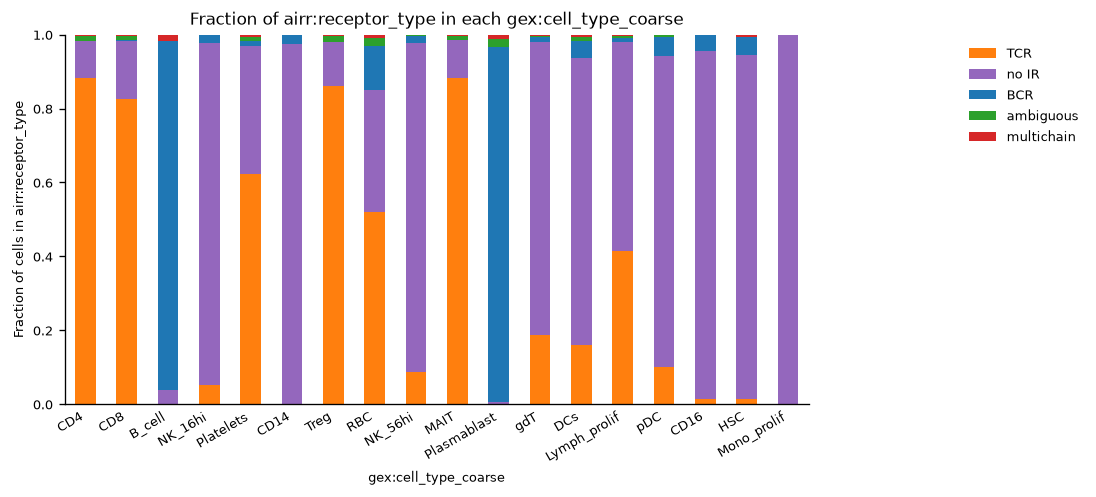

In [5]:
_ = ir.pl.group_abundance(
    mdata,
    groupby="gex:cell_type_coarse",
    target_col="airr:receptor_type",
    normalize=True,
    figsize=(8, 4),
)

Most T cells and MAIT cells carry a TCR, and most B cells and plasmablasts a BCR.
TCRs in NK cells or in cells annotated as platelets or red blood cells point to doublets, platelets bound to T cells or ambient RNA.
γδ T cells rarely have a TCR, since the V(D)J library only amplifies αβ chains.

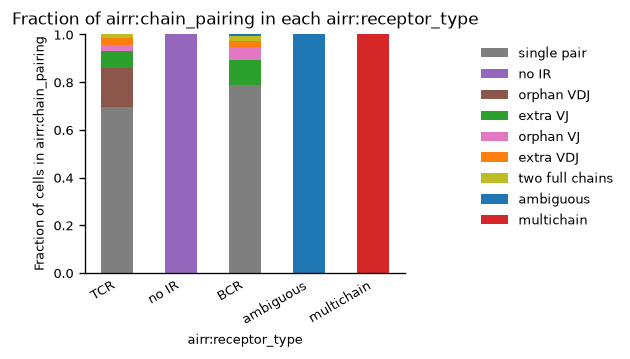

In [6]:
_ = ir.pl.group_abundance(
    mdata, groupby="airr:receptor_type", target_col="airr:chain_pairing", normalize=True
)

About 70% of T cells and 80% of B cells have a single pair of chains.
Most of the remaining T cells lack the α chain, which is detected less often than the β chain, whereas B cells more often carry a second light chain.

## Filtering

We remove cells with more chains than a cell can express and cells whose receptor does not match their cell type.
We keep orphan chains and flag them, since whether they are usable depends on the analysis.
Clonotypes defined by both chains cannot include them, whereas a database query of the β chain can.
From here on, we analyze T and B cells separately, since their receptors are treated differently.

In [7]:
t_cells = ["CD4", "CD8", "Treg", "MAIT", "gdT", "Lymph_prolif"]
b_cells = ["B_cell", "Plasmablast"]
receptor_type = mdata.obs["airr:receptor_type"]
cell_type = mdata.obs["gex:cell_type_coarse"]
mdata_tcr = mdata[(receptor_type == "TCR") & cell_type.isin(t_cells)].copy()
mdata_bcr = mdata[(receptor_type == "BCR") & cell_type.isin(b_cells)].copy()
for data in (mdata_tcr, mdata_bcr):
    data.obs = data.obs.apply(
        lambda col: (
            col.cat.remove_unused_categories() if col.dtype == "category" else col
        )
    )
mdata_tcr.n_obs, mdata_bcr.n_obs

(54137, 13422)

We store both objects for the [clonotype analysis](clonotype.ipynb).

In [8]:
ln.Artifact.from_mudata(
    mdata_tcr,
    key="air_repertoire/stephenson2021_tcr_qc.h5mu",
    description="T cells with TCRs of the Stephenson 2021 Cambridge samples after quality control",
).save()
ln.Artifact.from_mudata(
    mdata_bcr,
    key="air_repertoire/stephenson2021_bcr_qc.h5mu",
    description="B cells with BCRs of the Stephenson 2021 Cambridge samples after quality control",
).save()

→ creating new artifact version for key 'air_repertoire/stephenson2021_tcr_qc.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'


... uploading A54ugwVUlFz0PV5n0002.h5mu:  0.0%

... uploading A54ugwVUlFz0PV5n0002.h5mu:  7.1%

... uploading A54ugwVUlFz0PV5n0002.h5mu: 14.1%

... uploading A54ugwVUlFz0PV5n0002.h5mu: 28.2%

...

→ creating new artifact version for key 'air_repertoire/stephenson2021_bcr_qc.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'


... uploading ORrJ4xnxnhHL8smm0002.h5mu:  0.0%

... uploading ORrJ4xnxnhHL8smm0002.h5mu: 14.0%

... uploading ORrJ4xnxnhHL8smm0002.h5mu: 100.0%
• replacing the existing cache path /home/lheumos/.cache/lamindb/lamin-eu-central-1/VPwcjx3CDAa2/air_repertoire/stephenson2021_bcr_qc.h5mu


Artifact(uid='ORrJ4xnxnhHL8smm0002', key='air_repertoire/stephenson2021_bcr_qc.h5mu', description='B cells with BCRs of the Stephenson 2021 Cambridge samples after quality control', suffix='.h5mu', kind='dataset', otype='MuData', size=304891241, hash='c3Tz8USdyzyAKw5I5pv33h', n_files=None, n_observations=13422, extra_data=None, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=179, schema_id=None, created_by_id=2, created_at=2026-09-29 18:06:44 UTC, is_locked=False, version_tag=None, is_latest=True)

## Quiz

In [9]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card(
        "q1",
        "Why is the CDR3 the most diverse part of an immune receptor?",
        "It spans the junctions of the V, (D) and J gene segments, where nucleotides are randomly inserted and deleted during recombination.",
        back_font_size=15,
    )
    flip_card(
        "q2",
        "Why should BCRs be re-annotated with IgBLAST?",
        "Re-annotation against IMGT references reconstructs the germline sequences, which are needed to quantify somatic hypermutation.",
        back_font_size=15,
    )
    flip_card(
        "q3",
        "Which cells should be removed before clonotype analysis?",
        "Cells with more than two chains of a type or with both TCR and BCR chains, which are likely doublets, and cells whose receptor does not match their cell type.",
        back_font_size=15,
    )

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Felix Drost

### Reviewers

* Lukas Heumos